Isaac Noe
9/8/26
Lab 2 — Energy-Tracking Projectile

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Part A — Add Energy Tracking (25 points)

In [ ]:
# Part 1
# Defining the Function
def simulate_projectile_2d(v0, theta_deg, dt, m, g=9.81):

    # Initial conditions:
    angle = np.radians(theta_deg)
    x, y = 0.0, 0.0
    vx, vy = v0 * np.cos(angle), v0 * np.sin(angle)

    # Storage lists for plotting
    data = {'t': [0], 'x': [x], 'y': [y], 'vx': [vx], 'vy': [vy],
        'KE': [0.5*m*(vx**2+vy**2)], 'PE': [m*g*y], 'E': [0.5*m*(vx**2+vy**2)+m*g*y]}

    t = 0.0
    while y >= 0.0:
        # Compute acceleration (only gravity here)
        ax = 0.0
        ay = -g

        # Speed
        speed = np.sqrt(vx**2 + vy**2)

        # Update velocity (Euler)
        vx = vx + ax * dt
        vy = vy + ay * dt

        # Update position (Euler)
        x = x + vx * dt
        y = y + vy * dt

        t += dt

        # Energy tracking
        KE = 0.5 * m * (vx**2 + vy**2)
        PE = m * g * y
        E  = KE + PE
        
        data['t'].append(t)
        data['x'].append(x); data['y'].append(y)
        data['vx'].append(vx); data['vy'].append(vy)
        data['KE'].append(KE); data['PE'].append(PE); data['E'].append(E)
    return  data['t'], data['x'], data['y'], data['vx'], data['vy'], data['KE'], data['PE'], data['E']

In [ ]:
# Part 2 Setting Conditions
t, x, y, vx, vy, ke, pe, e = simulate_projectile_2d(30, 50, 0.01, 1)

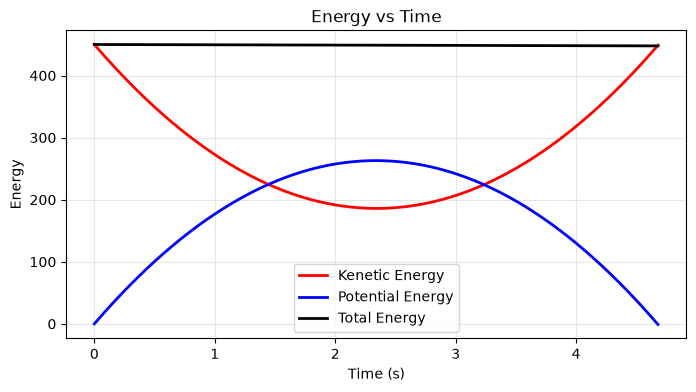

In [ ]:
# Part 3
# Plotting Graph 1
plt.figure(figsize=(8, 4))
plt.plot(t, ke, color='red', linewidth=2, label="Kenetic Energy")
plt.plot(t, pe,color="blue", linewidth=2, label="Potential Energy")
plt.plot(t, e,color="black", linewidth=2, label="Total Energy")
plt.xlabel('Time (s)')
plt.ylabel('Energy')
plt.title('Energy vs Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

This graph shows the relationship of Kenetic, Potential, and Total Energy as a function of time.

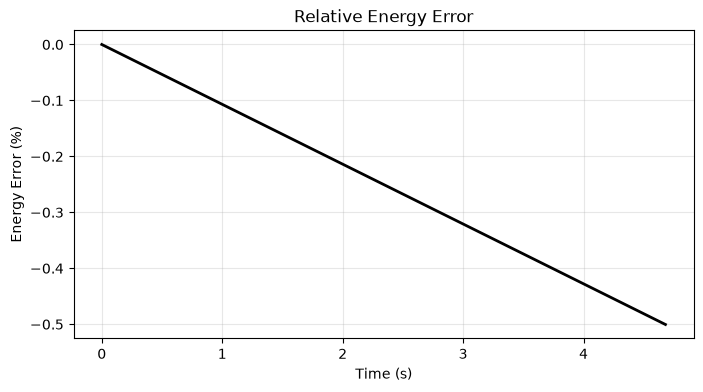

In [10]:
# Plotting Graph 2
E0 = e[0]
E_err = [(E - E0) / abs(E0) * 100 for E in e]
plt.figure(figsize=(8, 4))
plt.plot(t, E_err, color='black', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Energy Error (%)')
plt.title('Relative Energy Error')
plt.grid(True, alpha=0.3)
plt.show()

This graph shows energy drift as time progresses.